In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import sys
import multiprocessing
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
import EarthMotion
import parametrics
JD0 = 0
from emcee.autocorr import integrated_time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import corner


import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
from matplotlib.patches import Patch
import arviz as az

import logging
logging.getLogger("emcee.autocorr").setLevel(logging.ERROR)

from matplotlib.lines import Line2D

tref = 10063.874
coords = "17:57:38.03 -28:38:28.53"

VBM.t0_par = tref+JD0
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)

RA_str,Dec_str = "17:57:38.03","-28:38:28.53"
RA_deg = EarthMotion.hms_string_to_degrees(RA_str)
Dec_deg = EarthMotion.dms_string_to_degrees(Dec_str)
vEarth = EarthMotion.calc_vEarth(tref+2450000,RA_deg,Dec_deg)

gapmoe_model = gapmoe(RA_deg,Dec_deg)
gapmoe_model.set_data()

In [2]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [3]:

mpl.rc('font', **{'family': 'serif', 'serif': ['Liberation Serif', 'DejaVu Serif']})
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 15,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "0.3",
    "axes.linewidth": 1.4,
    "grid.alpha": 0.25,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [4]:
label_inds_kep = {"t0": 0, "tE": 1, "u0": 2, "rho": 3, "q": 4, "s": 5, "alpha": 6,
                  "piEN": 7, "piEE": 8, "gamma1": 9, "gamma2": 10, "gamma3": 11,
                  "rs": 12, "as": 13}

label_inds_kep_phys = {"ML": 3, "DL": 4, "DS": 5, "muN": 6, "muE": 7, "a": 8,
                       "e": 9, "cos_i": 10, "Omega": 11, "omega": 12, "nu": 13}

In [5]:
def read_chain(path,burnin,thin,flat=True):
    sampler = emcee.backends.HDFBackend(path)
    chain = sampler.get_chain(flat=flat, discard=burnin, thin=thin)
    blob = sampler.get_blobs(flat=flat, discard=burnin, thin=thin) 
    lnprob = sampler.get_log_prob(flat=flat, discard=burnin, thin=thin) 
    return chain, blob,lnprob

_chain,_blob,_lnprob = read_chain("../test_result/rogue1/backend/rerun_simu_02_kepler_chain_01.h5",0,1,flat=True)


In [6]:
ind = np.where((-0.4<_chain[:,7])&(_chain[:,7]<-0.2)&(0.1<_chain[:,8])&(_chain[:,8]<0.2) )
_chain,_blob,_lnprob = _chain[ind],_blob[ind],_lnprob[ind]

In [7]:
best_pr = _chain[np.argmax(_lnprob)]

In [8]:
loaded = np.load("/moao38_7/nunota/gapmoe/simu_data/simu_data_02_kepler.npz", allow_pickle=True)

simu_data = {k: loaded[k] for k in loaded.files}

def mag2flux(mag):
    return 10**(-mag / 2.5)

def flux2mag(flux):
    return -2.5 * np.log10(flux)

cVIBoya = 0.50141358
dVIBoya = 0.41968496
EVI, AI = 1.483,  1.822
def calc_thS(_fs_I,_fs_v):
    I_S = flux2mag(_fs_I)
    V_S = flux2mag(_fs_v)
    VI_S = V_S - I_S
    
    I0_S = I_S - AI
    VI0_S = VI_S - EVI
    
    _theta_star  = 0.5*10**(cVIBoya + dVIBoya*VI0_S  - 0.2*I0_S)
    return _theta_star

def linear_fit(x, y, w):
    w_sum = np.sum(w)
    wxy_sum = np.sum(w * x * y)
    wx_sum = np.sum(w * x)
    wy_sum = np.sum(w * y)
    wxx_sum = np.sum(w * x * x)

    bunbo = w_sum * wxx_sum - wx_sum ** 2

    if bunbo == 0 or not np.isfinite(bunbo):
        return np.nan, np.nan, np.inf

    a = (w_sum * wxy_sum - wx_sum * wy_sum) / bunbo
    b = (wxx_sum * wy_sum - wx_sum * wxy_sum) / bunbo

    if not (np.isfinite(a) and np.isfinite(b)):
        return np.nan, np.nan, np.inf

    y_fit = a * x + b
    chi2 = np.sum(w * (y - y_fit) ** 2)

    return a, b, chi2

def calc_ln_like(theta,source_flux=False):
    _t0 = theta[0]
    _tE     = theta[1]
    _u0 = theta[2]
    _rho    = theta[3]
    _q = theta[4]
    _s      = theta[5]
    _alpha = theta[6]
    _piEN   = theta[7]
    _piEE   = theta[8]
    _gamma1 = theta[9]
    _gamma2 = theta[10]
    _gamma3 = theta[11]
    _rs = theta[12]
    _as = theta[13] 
    _pr = [math.log(_s), math.log(_q), _u0, _alpha, math.log(_rho), math.log(_tE), _t0+JD0, _piEN, _piEE, _gamma1,_gamma2,_gamma3,_rs,_as]

    _chi2_sum = 0
    for _name in simu_data.keys():
        _model_amp = np.array(VBM.BinaryLightCurveKepler(_pr,simu_data[_name]["time"]+JD0)[0])
        _fs,_fb,_chi2 = linear_fit(_model_amp,simu_data[_name]["flux_obs"],simu_data[_name]["ferr"]**(-2))
        _chi2_sum += _chi2
        if _name == 'MOA_Red':
            _fs_i = _fs
        if _name == 'MOA_V':
            _fs_v = _fs

    if source_flux:
        return -0.5*_chi2_sum, _fs_i, _fs_v
    else:
        return -0.5*_chi2_sum

def check_eccentricity(theta):
    s      = theta[5]
    gamma1 = theta[9]
    gamma2 = theta[10]
    gamma3 = theta[11]
    r_s = theta[12]
    a_s = theta[13] + 1e-8 

    GM_by_RE3_s3 = a_s * np.sqrt(1+r_s**2) * (gamma1**2 + gamma2**2 + gamma3**2)/(2*a_s - 1)

    r = jnp.array([1,0, r_s])
    v = jnp.array([gamma1,gamma2,gamma3])
    
    h = jnp.cross(r,v)
    A = jnp.cross(v,h) / GM_by_RE3_s3  - r / jnp.sqrt(jnp.dot(r,r))
    e = jnp.sqrt(jnp.dot(A,A))

    return e < 0.99
    
def calc_ln_prior(theta):
    _t0     = theta[0]
    _tE     = theta[1]
    _u0     = theta[2]
    _rho    = theta[3]
    _q      = theta[4]
    _s      = theta[5]
    _alpha  = theta[6]
    _piEN   = theta[7]
    _piEE   = theta[8]
    _gamma1 = theta[9]
    _gamma2 = theta[10]
    _gamma3 = theta[11]
    _rs     = theta[12]
    _as     = theta[13]

    if not (10000 <= _t0 <= 11000): return -np.inf
    if not (0 < _tE <= 1000): return -np.inf
    if not (-5 <= _u0 <= 5): return -np.inf
    if not (0 < _rho <= 1): return -np.inf
    if not (1e-5 <= _q <= 1): return -np.inf
    if not (0 < _s <= 5): return -np.inf
    if not (-np.pi <= _alpha <= np.pi): return -np.inf
    if not (-3 <= _piEN <= 3): return -np.inf
    if not (-3 <= _piEE <= 3): return -np.inf
    if not (-1 <= _gamma1 <= 1): return -np.inf
    if not (-1 <= _gamma2 <= 1): return -np.inf
    if not (-1 <= _gamma3 <= 1): return -np.inf
    if not (-10 <= _rs <= 10): return -np.inf
    if not (0 <= _as <= 10): return -np.inf

    return -np.log(_q)

def ln_prob(theta):
    _ln_prior = calc_ln_prior(theta)
        
    if jnp.isneginf(_ln_prior):
        return -jnp.inf, np.nan

    if not check_eccentricity(theta):
        return -np.inf, np.nan  

    _ln_like, _fs_i, _fs_v = calc_ln_like(theta,source_flux=True)
    if jnp.isnan(_fs_i) or jnp.isnan(_fs_v) or jnp.isneginf(_ln_like):
        return -jnp.inf, np.nan

    _thS = calc_thS(_fs_i,_fs_v)

    ln_post = _ln_like + _ln_prior
    return ln_post

In [9]:
chi2_list = []
piE_fix = np.sqrt(0.2**2 + 0.15**2)
for phi in np.linspace(0,2*np.pi,36):
    _pr = best_pr.copy()
    _pr[7] = piE_fix * np.cos(phi)
    _pr[8] = piE_fix * np.sin(phi)
    chi2_list.append(-2*ln_prob(_pr))

In [42]:
chain_para = np.load("../test_result/array/kep_wo_chain_02.npy")[:,:9]
para_phi = np.arctan2(chain_para[:,8],chain_para[:,7])
para_phi_unwrap = np.unwrap(para_phi)
para_16, para_50, para_84 = np.percentile(para_phi_unwrap, [16,50,84])

piEN_true = 0.128858
piEE_true =  0.136441
phi_true = np.arctan2(piEE_true,piEN_true)

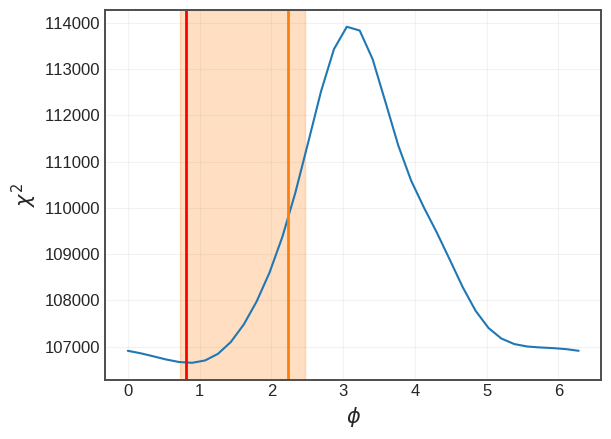

In [43]:
plt.plot(np.linspace(0,2*np.pi,36),chi2_list)
plt.axvspan(para_16, para_84, color="C1", alpha=0.25)
plt.axvline(para_50, color="C1", lw=2)
plt.axvline(phi_true, color="red", lw=2)

plt.xlabel(r"$\phi$")
plt.ylabel(r"$\chi^2$")

plt.show()

In [44]:
chi2_list = []
piE_fix = np.sqrt(piEN_true**2 + piEE_true**2)
for phi in np.linspace(0,2*np.pi,36):
    _pr = best_pr.copy()
    _pr[7] = piE_fix * np.cos(phi)
    _pr[8] = piE_fix * np.sin(phi)
    chi2_list.append(-2*ln_prob(_pr))

In [45]:
chain_para = np.load("../test_result/array/kep_wo_chain_02.npy")[:,:9]
para_phi = np.arctan2(chain_para[:,8],chain_para[:,7])
para_phi_unwrap = np.unwrap(para_phi)
para_16, para_50, para_84 = np.percentile(para_phi_unwrap, [16,50,84])

piEN_true = 0.128858
piEE_true =  0.136441
phi_true = np.arctan2(piEE_true,piEN_true)

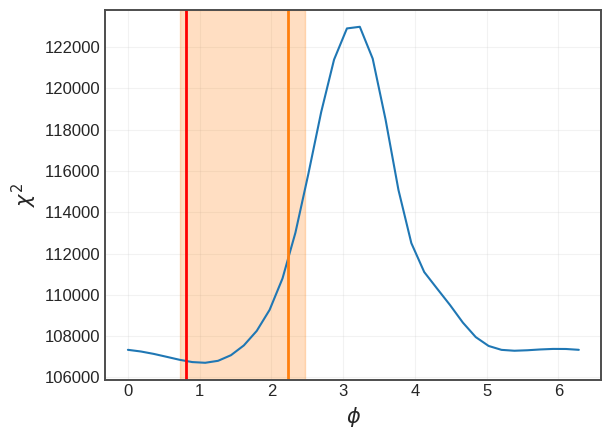

In [46]:
plt.plot(np.linspace(0,2*np.pi,36),chi2_list)
plt.axvspan(para_16, para_84, color="C1", alpha=0.25)
plt.axvline(para_50, color="C1", lw=2)
plt.axvline(phi_true, color="red", lw=2)

plt.xlabel(r"$\phi$")
plt.ylabel(r"$\chi^2$")
plt.show()
plt.show()

In [47]:
chi2_list = []
piE_fix = np.sqrt(0.1**2 + 0.1**2)
for phi in np.linspace(0,2*np.pi,36):
    _pr = best_pr.copy()
    _pr[7] = piE_fix * np.cos(phi)
    _pr[8] = piE_fix * np.sin(phi)
    chi2_list.append(-2*ln_prob(_pr))

In [50]:
chain_para = np.load("../test_result/array/kep_gap_chain_02.npy")[:,:9]
para_phi = np.arctan2(chain_para[:,8],chain_para[:,7])
para_phi_unwrap = np.unwrap(para_phi)
para_16, para_50, para_84 = np.percentile(para_phi_unwrap, [16,50,84])

piEN_true = 0.128858
piEE_true =  0.136441
phi_true = np.arctan2(piEE_true,piEN_true)

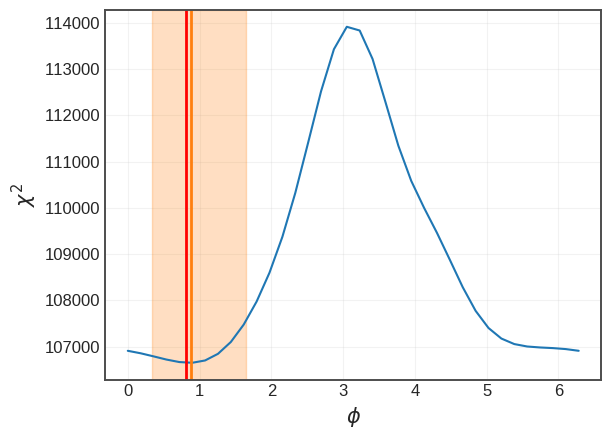

In [51]:
plt.plot(np.linspace(0,2*np.pi,36),chi2_list)
plt.axvspan(para_16, para_84, color="C1", alpha=0.25)
plt.axvline(para_50, color="C1", lw=2)
plt.axvline(phi_true, color="red", lw=2)

plt.xlabel(r"$\phi$")
plt.ylabel(r"$\chi^2$")
plt.show()
plt.show()